In [ ]:
import polars as pl
# Lê apenas a primeira linha para ver o "cabeçalho"
schema = pl.read_parquet("statsbomb_completo.parquet", n_rows=1).columns
print("📋 Colunas reais do arquivo:", schema)

In [18]:
import polars as pl
import numpy as np
import os

# Garantir que a pasta de destino existe
os.makedirs("Data/Gold", exist_ok=True)

print("⚡ Carregando e processando dados (1M linhas)...")

# 1. CARGA SELETIVA
df = pl.read_parquet("statsbomb_completo.parquet", n_rows=1000000)
df = df.rename({col: col.replace(".", "_") for col in df.columns}).sort(["match_id", "index"])

# 2. FEATURES GEOMÉTRICAS
df = df.with_columns([
    pl.col("location").list.get(0).fill_null(120.0).alias("x"),
    pl.col("location").list.get(1).fill_null(40.0).alias("y"),
    pl.col("under_pressure").fill_null(False).cast(pl.Int8).alias("pressao_binaria")
])

x_arr, y_arr = df["x"].to_numpy(), df["y"].to_numpy()
dist = np.sqrt((120 - x_arr)**2 + (40 - y_arr)**2)

# Lei dos Cossenos para o ângulo de visão
a = np.sqrt((120 - x_arr)**2 + (36 - y_arr)**2)
b = np.sqrt((120 - x_arr)**2 + (44 - y_arr)**2)
cos_theta = np.clip((a**2 + b**2 - 8**2) / (2 * a * b), -1.0, 1.0)
angulo = np.degrees(np.arccos(cos_theta))

# 3. FEATURES TEMPORAIS E CONTEXTO
df_contexto = df.with_columns([
    pl.Series("distancia", dist),
    pl.Series("angulo_visao", angulo),
    pl.col("pressao_binaria").rolling_mean(window_size=10, min_samples=1).over("match_id").alias("pressao_10_lances"),
    (pl.col("x") - pl.col("x").shift(5).over("match_id")).alias("aceleracao_ataque"),
    (pl.col("x") - pl.col("x").shift(1).over("match_id")).alias("progresso_ultimo_lance")
])

# 4. TARGET: Iminência (Janela de 10 eventos)
df_total = df_contexto.with_columns([
    (pl.col("type_name") == "Shot").cast(pl.Int8).alias("eh_chute")
]).with_columns([
    pl.col("eh_chute")
      .shift(-10)
      .rolling_max(window_size=10, min_samples=1)
      .over("match_id")
      .fill_null(0)
      .alias("iminencia_gol")
])

# ====================== 5. O SPLIT ESTRATÉGICO ======================

# --- DATASET 1: ATAQUE (O Filé Mignon para o XGBoost) ---
features_treino = [
    "match_id", "player_name", "x", "y", "distancia", 
    "angulo_visao", "pressao_10_lances", "aceleracao_ataque", 
    "progresso_ultimo_lance", "iminencia_gol"
]

df_ataque = df_total.filter(
    pl.col("type_name").is_in(["Pass", "Carry", "Dribble", "Ball Recovery"])
).select(features_treino).fill_null(0)

# --- DATASET 2: DEFESA/GOLEIRO (O "Dicionário" de resultados) ---
# Pegamos colunas que explicam por que um gol NÃO aconteceu (bloqueios e defesas)
cols_defesa = ["match_id", "index", "player_name", "type_name"] + \
              [c for c in df_total.columns if "goalkeeper" in c or "block" in c or "foul" in c]

df_defesa = df_total.select(cols_defesa).filter(
    pl.col("type_name").is_in(["Goalkeeper", "Block", "Foul Committed", "Foul Won"])
)

# 6. SALVANDO OS RESULTADOS
df_ataque.write_parquet("Data/Gold/ataque_oraculo.parquet")
df_defesa.write_parquet("Data/Gold/defesa_lookup.parquet")

print("-" * 30)
print(f"✅ DATASET ATAQUE: {df_ataque.height:,} linhas | {df_ataque.width} colunas")
print(f"🛡️ DATASET DEFESA: {df_defesa.height:,} linhas | {df_defesa.width} colunas")
print(f"📊 Taxa de Iminência: {df_ataque['iminencia_gol'].mean():.2%}")
print("-" * 30)

⚡ Carregando e processando dados (1M linhas)...
------------------------------
✅ DATASET ATAQUE: 543,005 linhas | 10 colunas
🛡️ DATASET DEFESA: 23,953 linhas | 37 colunas
📊 Taxa de Iminência: 6.85%
------------------------------


In [20]:
df_ataque.head(15)

match_id,player_name,x,y,distancia,angulo_visao,pressao_10_lances,aceleracao_ataque,progresso_ultimo_lance,iminencia_gol
str,str,f64,f64,f64,f64,f64,f64,f64,i8
"""15946""","""Jonathan Rodríguez Menéndez""",61.0,40.1,59.000085,7.757027,0.0,0.0,-59.0,0
"""15946""","""Guillermo Alfonso Maripán Loay…",33.8,28.0,87.031259,5.212992,0.0,-86.2,0.0,0
"""15946""","""Guillermo Alfonso Maripán Loay…",36.8,27.3,84.16371,5.380086,0.0,-83.2,3.0,0
"""15946""","""Sergio Busquets i Burgos""",33.6,5.9,92.88579,4.588851,0.2,-0.2,-52.9,0
"""15946""","""Ivan Rakitić""",35.1,18.3,87.629333,5.065166,0.2,-1.7,0.0,0
…,…,…,…,…,…,…,…,…,…
"""15946""","""Víctor Laguardia Cisneros""",35.8,69.7,89.284545,4.839607,0.0,1.5,5.8,0
"""15946""","""Marc-André ter Stegen""",13.7,24.3,107.453153,4.218171,0.0,-11.6,-22.1,0
"""15946""","""Marc-André ter Stegen""",13.7,24.3,107.453153,4.218171,0.0,-12.0,0.0,0


🚀 Iniciando validação REAL + SHAP do Oráculo de ATAQUE...
⚖️ Peso de equilíbrio: 13.60
Fold 1 → AUC: 0.7809 | Brier: 0.1791
Fold 2 → AUC: 0.7918 | Brier: 0.1713
Fold 3 → AUC: 0.7890 | Brier: 0.1720
Fold 4 → AUC: 0.7885 | Brier: 0.1790
Fold 5 → AUC: 0.7750 | Brier: 0.1698

✅ AUC MÉDIO REAL (5 folds): 0.7850 ± 0.0062
🎯 Brier médio: 0.1742

📊 Gerando SHAP e Feature Importance...


<Figure size 1000x600 with 0 Axes>

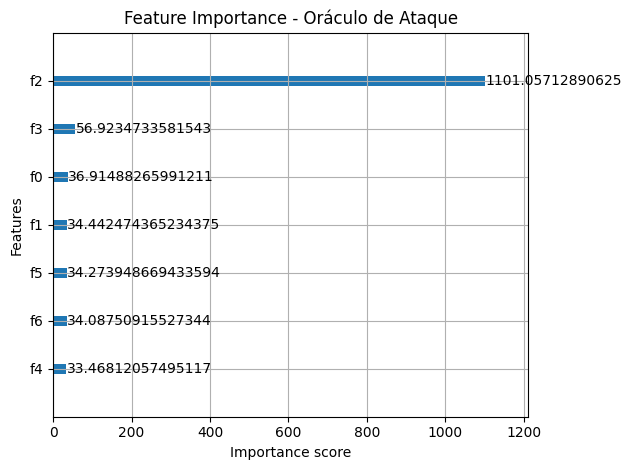

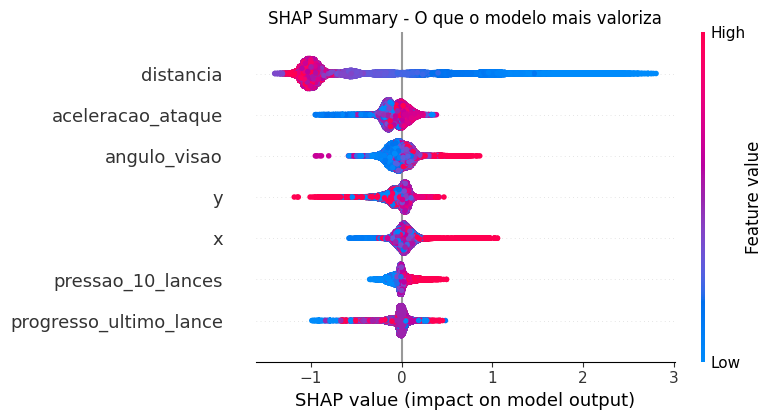


🔮 Exemplo de predição em tempo real (últimos 10 lances do dataset):
Lance  1 | x=114.5 y=70.3 | Dist=30.8m | Ângulo=2.7° | Prob. de chute em 10 lances = 73.2%
Lance  2 | x=117.3 y=73.6 | Dist=33.7m | Ângulo=1.1° | Prob. de chute em 10 lances = 59.7%
Lance  3 | x=1.6 y=31.7 | Dist=118.7m | Ângulo=3.9° | Prob. de chute em 10 lances = 34.9%
Lance  4 | x=120.0 y=80.0 | Dist=40.0m | Ângulo=0.0° | Prob. de chute em 10 lances = 82.0%
Lance  5 | x=116.2 y=76.5 | Dist=36.7m | Ângulo=1.3° | Prob. de chute em 10 lances = 62.7%
Lance  6 | x=117.8 y=72.5 | Dist=32.6m | Ângulo=1.0° | Prob. de chute em 10 lances = 77.1%
Lance  7 | x=110.7 y=40.1 | Dist=9.3m | Ângulo=46.5° | Prob. de chute em 10 lances = 94.1%
Lance  8 | x=11.6 y=45.1 | Dist=108.5m | Ângulo=4.2° | Prob. de chute em 10 lances = 45.8%
Lance  9 | x=11.6 y=45.1 | Dist=108.5m | Ângulo=4.2° | Prob. de chute em 10 lances = 28.7%
Lance 10 | x=11.6 y=45.1 | Dist=108.5m | Ângulo=4.2° | Prob. de chute em 10 lances = 28.3%

💾 Modelo final salvo 

In [10]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
import numpy as np
import shap
import matplotlib.pyplot as plt

print("🚀 Iniciando validação REAL + SHAP do Oráculo de ATAQUE...")

PATH = "Data/atacks_defense/ataque_oraculo.parquet"
df_ml = pd.read_parquet(PATH)

features = [
    'x', 'y', 'distancia', 'angulo_visao',
    'pressao_10_lances', 'aceleracao_ataque', 'progresso_ultimo_lance'
]

X = df_ml[features].values
y = df_ml['iminencia_gol'].values
groups = df_ml['match_id'].values

pos_weight = (len(y) - y.sum()) / y.sum()
print(f"⚖️ Peso de equilíbrio: {pos_weight:.2f}")

gkf = GroupKFold(n_splits=5)
auc_scores = []
brier_scores = []
models = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), 1):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    model = xgb.XGBClassifier(
        n_estimators=800,
        max_depth=7,
        learning_rate=0.04,
        scale_pos_weight=pos_weight,
        tree_method='hist',
        eval_metric='auc',
        early_stopping_rounds=60,
        random_state=42 + fold
    )
    
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    
    probas = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, probas)
    brier = brier_score_loss(y_test, probas)
    
    auc_scores.append(auc)
    brier_scores.append(brier)
    models.append(model)
    
    print(f"Fold {fold} → AUC: {auc:.4f} | Brier: {brier:.4f}")

print("\n" + "="*60)
print(f"✅ AUC MÉDIO REAL (5 folds): {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"🎯 Brier médio: {np.mean(brier_scores):.4f}")
print("="*60)

# ====================== SHAP + IMPORTANCE (último fold) ======================
best_model = models[-1]
print("\n📊 Gerando SHAP e Feature Importance...")

# Feature Importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(best_model, importance_type='gain', max_num_features=10, title="Feature Importance - Oráculo de Ataque")
plt.tight_layout()
plt.show()

# SHAP Summary (usa os dados do último fold)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=features, show=False)
plt.title("SHAP Summary - O que o modelo mais valoriza")
plt.tight_layout()
plt.show()

# ====================== EXEMPLO DE PREDIÇÃO AO VIVO ======================
print("\n🔮 Exemplo de predição em tempo real (últimos 10 lances do dataset):")
exemplo = df_ml[features].tail(10)
pred_exemplo = best_model.predict_proba(exemplo)[:, 1]

for i, (idx, row) in enumerate(exemplo.iterrows()):
    prob = pred_exemplo[i]
    print(f"Lance {i+1:2d} | x={row['x']:.1f} y={row['y']:.1f} | "
          f"Dist={row['distancia']:.1f}m | Ângulo={row['angulo_visao']:.1f}° | "
          f"Prob. de chute em 10 lances = {prob:.1%}")

# ====================== SALVAMENTO ======================
best_model.save_model("oraculo_iminencia_ATAQUE_vFINAL.json")
print("\n💾 Modelo final salvo como 'oraculo_iminencia_ATAQUE_vFINAL.json'")
print("✅ Tudo pronto para usar ao vivo!")